In [1]:
import warnings
warnings.filterwarnings("ignore")
import logging
from statkit.decision import NetBenefitDisplay

import pandas as pd
import seaborn as sns
import numpy as np
import shap 
import torch
import os
import inspect 
import torch.nn as nn
import matplotlib.pyplot as plt
import pickle
from numpy import sqrt
from numpy import argmax
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from matplotlib import pyplot
from torchinfo import summary as torchsummary
from torchvision import models, transforms
from model import init_model
from matplotlib import pyplot
from pathlib import Path
sns.set(rc={'figure.figsize':(11.7,8.27)})
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999




In [2]:
ROOT_DIR = Path(os.path.dirname(os.path.abspath('')))
TOTAL_TRAIN_SAMPLES = 50
TOTAL_TEST_SAMPLES = 10
CHANNELS = 3
DEVICE = "cuda:1"
OCT_PRESENCE = "Usando OCT"
DUAL_IMAGE = "Dual Image"
DATA_PATH = "../data.csv"
SUMMARY_PATH = "../model_summary.csv"
HISTORY_PATH = "../history.csv"
FT_SIZE = 24
ARQ1 = "SI"
ARQ2 = "SIT"
ARQ3 = "DI"
ARQ4 = "DIT"

In [3]:
def get_samples_from_dataloader(dataloader, size):
    """
        Return photos1, photos2, ft_numerical, labels
    """ 
    
    list_of_photos_1 = []
    list_of_photos_2 = []
    list_of_features = []
    list_of_labels = []

    
    positive_class = 0
    negative_class = 0 
    
    for photos1, photos2, numericalft, labels in dataloader:
        for i in range(len(labels)):
            if int(labels[i].numpy()) == 0 and negative_class >= (size / 2):
                continue
            elif int(labels[i].numpy()) == 0 and negative_class < (size / 2):
                negative_class += 1
                
            if int(labels[i].numpy()) == 1 and positive_class >= (size / 2):
                continue 
            elif int(labels[i].numpy()) == 1 and positive_class < (size / 2):
                positive_class += 1
                
            list_of_photos_1.append(photos1[i])
            list_of_photos_2.append(photos2[i])
            list_of_features.append(numericalft[i])
            list_of_labels.append(labels[i].numpy())
        
        if len(list_of_labels) >= size:
            break
        
    
            
    photos1 = torch.stack(list_of_photos_1)
    photos2 = torch.stack(list_of_photos_2)
    ft_numerical = torch.stack(list_of_features)
    labels  = np.array(list_of_labels)
    
    return (photos1, photos2, ft_numerical, labels)


In [4]:
def load_model_and_loaders(model_row):
    """
        Return model, train_loader, val_loader
    """ 
    model_name = model_row["backbone"].values[0]
    pretrained = False
    feature_extract = False
    double_img_bool = True if model_row["double_img"].values[0] > 0 else False
    output_tab = int(model_row["output_tab"].values[0]) if model_row["output_tab"].values[0] > 0 else None 
    model, input_size = init_model(model_name,pretrained, feature_extract, double_img_bool, output_tab, FT_SIZE)
    model.load_state_dict(torch.load("../models/" + str(model_id) + "/" + "model"+ ".pth"))
    train_loader = torch.load("../models/" + str(model_id) + "/train_dataloader" + ".pth")
    val_loader = torch.load("../models/" + str(model_id) + "/val_dataloader" + ".pth")
    
    val_loader.dataset.root_dir = ROOT_DIR
    train_loader.dataset.root_dir = ROOT_DIR
    
    return model, train_loader, val_loader, input_size

In [5]:
def create_explainers(model, device, photos1_train, photos2_train, ft_numerical_train, 
                                     photos1_val, photos2_val, ft_numerical_val, input_size):
    """
        Return shap_values_photo1, shap_values_photo2, shap_values_nuermical
    """ 
    
    model = model.to(device)
    explainer = shap.DeepExplainer(model, [photos1_train.to(device),photos2_train.to(device),ft_numerical_train.to(device)])
    shap_values_photo1, shap_values_photo2, shap_values_numerical = explainer.shap_values([photos1_val.to(device),photos2_val.to(device), ft_numerical_val.to(device)])
    
    photos1_list = []
    photos2_list = []
    for i in range(len(photos1_val)):
        photos1_list.append(imshow(photos1_val[i]))
        photos2_list.append(imshow(photos2_val[i]))
        
    
    photos1_numpy = np.asarray(photos1_list)
    photos2_numpy = np.asarray(photos2_list)
    
    return (shap_values_photo1.reshape(-1, input_size, input_size, CHANNELS), 
            shap_values_photo2.reshape(-1, input_size, input_size, CHANNELS), 
            shap_values_numerical,
            photos1_numpy, 
            photos2_numpy)

In [6]:
def plot_image(shap_values, photos, total):
    
    return shap.image_plot(shap_values[:total], photos[:total])

In [7]:
def imshow(image):
    npimg = image.numpy()
    npimg = np.transpose(npimg, (1,2,0))
    npimg = ((npimg * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406])
    return npimg

In [8]:
def shapley_feature_ranking(shap_values):
    feature_order = np.argsort(np.mean(np.abs(shap_values), axis=0))
    return pd.DataFrame(
        {
            "features": [features_name[i] for i in feature_order][::-1],
            "importance": [
                np.mean(np.abs(shap_values), axis=0)[i] for i in feature_order
            ][::-1],
        }
    )

In [9]:
def get_rank_per_group(df_max,df_avg):
    dict_rows = {}
    dict_rows["Backbone"] = []
    dict_rows[OCT_PRESENCE] = []
    dict_rows[DUAL_IMAGE] = []
    dict_rows["Max Auc Rank"] = []
    dict_rows["Avg Auc Rank"] = []
 
 
    df_max = df_max.sort_values(by=["backbone",OCT_PRESENCE,DUAL_IMAGE])
    df_avg = df_avg.sort_values(by=["backbone",OCT_PRESENCE,DUAL_IMAGE])
    
    
    for index, row in df_max.iterrows():
        dict_rows["Backbone"].append(row["backbone"])
        dict_rows[OCT_PRESENCE].append(row[OCT_PRESENCE])
        dict_rows[DUAL_IMAGE].append(row[DUAL_IMAGE])
        dict_rows["Max Auc Rank"].append(row["rank_max_auc_oct_double"])
        
    for index, row in df_avg.iterrows():
        dict_rows["Avg Auc Rank"].append(row["rank_avg_auc_oct_double"])
        
    df_rank_per_group = pd.DataFrame.from_dict(dict_rows)
    return df_rank_per_group

In [10]:
data = pd.read_csv(DATA_PATH)
summary = pd.read_csv(SUMMARY_PATH)
filter_summary = pd.read_csv("../filter_top1.csv")
df_peak = pd.read_csv("../df_peak_mem_summary.csv")

In [19]:
summary[summary["model_id"] == "1c6f3dc7ee844662b288be93b1c91235"]

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,optim,lr,scheduler,randaugop,epochs,double_img,output_tab,backbone,early_start,patient_el,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,history_added,shap_val,shap_oos,pred_val,pred_oos,batch_size,Usando OCT,Dual Image,group_backbone,regnet_vs_other,rank_max_auc,rank_avg_auc,Unnamed: 47,Unnamed: 46,rank_max_auc_oct_double,rank_avg_auc_oct_double,rank_avg,Unnamed: 50,Unnamed: 51,inference_time,Unnamed: 55
865,1c6f3dc7ee844662b288be93b1c91235,5.0,NaN,0.947368,0.944562,1.0,0.954545,0.871546,0.81753,0.937668,0.697391,0.978583,0.972441,1.0,0.95858,0.916915,0.87761,0.9678,0.787419,magneto,adam,0.0005,plateau,0,100.0,0.0,5.0,regnet32y,30.0,10,2022-12-20 17:05:17.191984,40:54:24.74,08:10:52.93,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
summary.sort_values("val_best_auc",ascending=False).head()

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,optim,lr,scheduler,randaugop,epochs,double_img,output_tab,backbone,early_start,patient_el,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,history_added,shap_val,shap_oos,pred_val,pred_oos,batch_size,Usando OCT,Dual Image,group_backbone,regnet_vs_other,rank_max_auc,rank_avg_auc,Unnamed: 47,Unnamed: 46,rank_max_auc_oct_double,rank_avg_auc_oct_double,rank_avg,Unnamed: 50,Unnamed: 51,inference_time,Unnamed: 55
884,b674627d958947d79102841cdd7e2d90,5.0,NaN,0.986755,0.990654,1.0,1.000000,0.913400,0.873079,0.968750,0.777408,0.963756,0.944110,1.0,0.908537,0.926337,0.883533,0.981349,0.785717,magneto,radam,0.010,plateau,0,100.0,0.0,5.0,regnet16x,30.0,10,2022-12-25 02:14:46.574350,42:03:33.52,08:24:42.68,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
878,6c92c468c77746fab4010a6a0f6e21d4,5.0,NaN,0.993377,0.988636,1.0,1.000000,0.907971,0.875812,0.952785,0.798839,0.970346,0.952802,1.0,0.916201,0.932093,0.894174,0.980556,0.807792,magneto,radam,0.010,plateau,0,100.0,0.0,5.0,regnet16y,30.0,10,2022-12-22 20:36:01.720669,48:02:25.93,09:36:29.16,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
893,76dc260776a24cfab89591e7c9b61571,5.0,NaN,0.993377,0.988636,1.0,0.977273,0.912041,0.870557,0.967679,0.773435,0.965404,0.943656,1.0,0.902439,0.928965,0.887132,0.982651,0.791614,magneto,radam,0.010,<torch.optim.lr_scheduler.ReduceLROnPlateau ob...,4,100.0,0.0,5.0,regnet16x,30.0,10,2022-12-30 17:28:40.523340,92:54:40.47,18:34:56.07,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.091,NaN
870,4b9591039ed648d5b4f444e7e8952f7b,5.0,NaN,0.993377,0.988636,1.0,1.000000,0.914840,0.879143,0.964147,0.794138,0.970346,0.954319,1.0,0.927374,0.933543,0.898307,0.978393,0.818220,magneto,radam,0.010,plateau,0,100.0,0.0,5.0,shuffle,30.0,10,2022-12-20 18:42:52.520324,42:26:44.05,08:29:20.78,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
875,a466a38bb66140d7b7a543a10dcf02cf,5.0,NaN,0.980132,0.985981,1.0,1.000000,0.894026,0.852266,0.949503,0.755030,0.971993,0.962423,1.0,0.940828,0.922622,0.883144,0.973418,0.792870,magneto,adam,0.001,plateau,0,100.0,0.0,5.0,regnetx,30.0,10,2022-12-22 19:46:29.230808,47:10:07.09,09:26:01.39,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
pred = pd.read_csv("../models/65373da88d434c8eb46f6a281075dfb4/model_fold_1_pred.csv")
pred2 = pd.read_csv("../models/65373da88d434c8eb46f6a281075dfb4/model_fold_2_pred.csv")
pred3 = pd.read_csv("../models/65373da88d434c8eb46f6a281075dfb4/model_fold_3_pred.csv")
pred4 = pd.read_csv("../models/65373da88d434c8eb46f6a281075dfb4/model_fold_4_pred.csv")
pred5 = pd.read_csv("../models/65373da88d434c8eb46f6a281075dfb4/model_fold_5_pred.csv")

In [39]:
y_true = pred[pred["dataset"] == "oos"]["true"].values
y_true2 = pred2[pred2["dataset"] == "oos"]["true"].values
y_true3 = pred3[pred3["dataset"] == "oos"]["true"].values
y_true4 = pred4[pred4["dataset"] == "oos"]["true"].values
y_true5 = pred5[pred5["dataset"] == "oos"]["true"].values

yhat1 = pred[pred["dataset"] == "oos"]["pred_sigmoid"].values
yhat2 = pred2[pred2["dataset"] == "oos"]["pred_sigmoid"].values
yhat3 = pred3[pred3["dataset"] == "oos"]["pred_sigmoid"].values
yhat4 = pred4[pred4["dataset"] == "oos"]["pred_sigmoid"].values
yhat5 = pred5[pred5["dataset"] == "oos"]["pred_sigmoid"].values

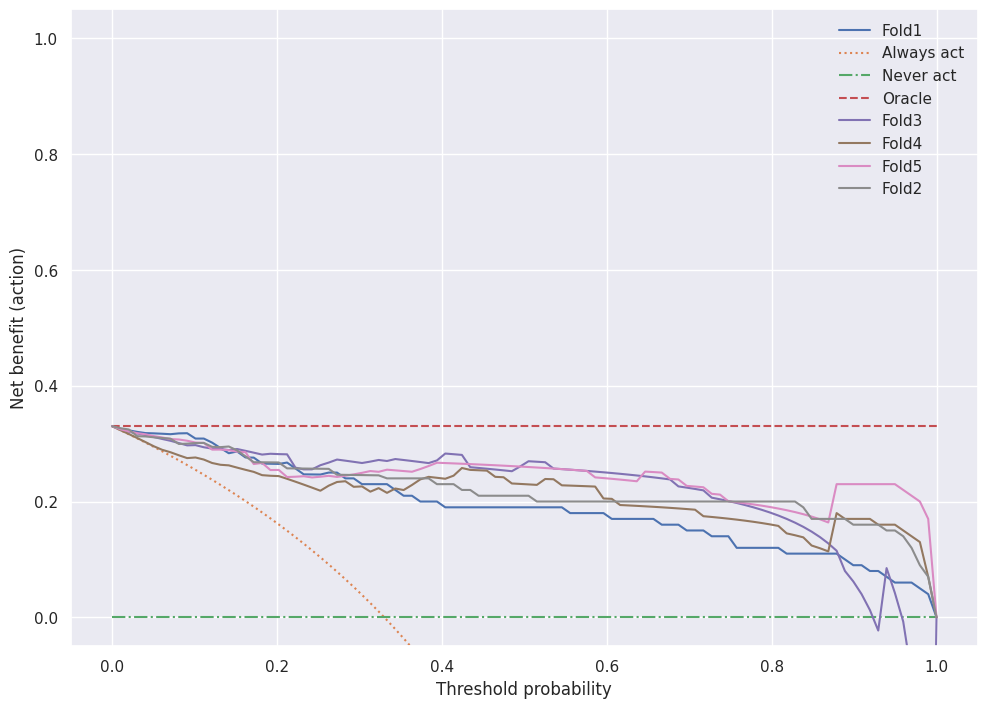

In [50]:
NetBenefitDisplay.from_predictions(y_true, yhat1, name='Fold1',show_references=True, ax=plt.gca())
NetBenefitDisplay.from_predictions(y_true3, yhat3, name='Fold3',show_references=False, ax=plt.gca())
NetBenefitDisplay.from_predictions(y_true4, yhat4, name='Fold4',show_references=False, ax=plt.gca())
NetBenefitDisplay.from_predictions(y_true5, yhat5, name='Fold5',show_references=False, ax=plt.gca())
NetBenefitDisplay.from_predictions(y_true2, yhat2, name='Fold2',show_references=False, ax=plt.gca())

In [68]:
fpr, tpr, thresholds = roc_curve(y_true5, yhat5)
auc(fpr, tpr)

0.95838986883763

Best Threshold=0.576721, G-Mean=0.907


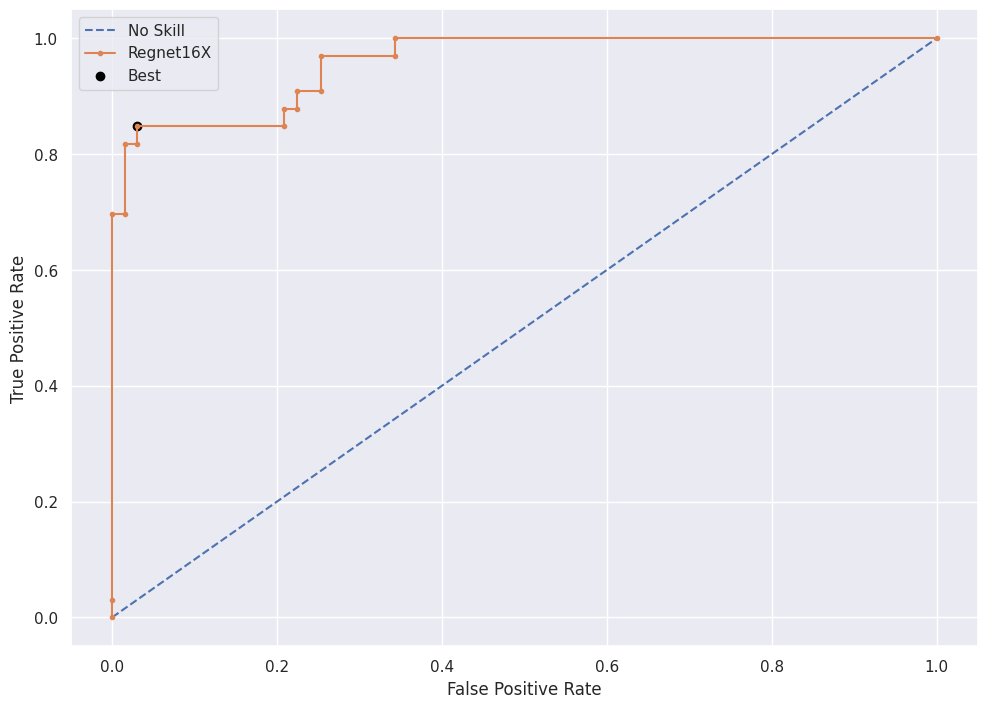

In [70]:

# calculate the g-mean for each threshold
gmeans = sqrt(tpr * (1-fpr))
# locate the index of the largest g-mean
ix = argmax(gmeans)
print('Best Threshold=%f, G-Mean=%.3f' % (thresholds[ix], gmeans[ix]))
# plot the roc curve for the model
pyplot.plot([0,1], [0,1], linestyle='--', label='No Skill')
pyplot.plot(fpr, tpr, marker='.', label='Regnet16X')
pyplot.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()
# show the plot
pyplot.show()